<a href="https://colab.research.google.com/github/ExpiredSession/DataScience_HW/blob/main/HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np

# Define the path to the uploaded Tokyo Airbnb dataset in your Drive
file_path = '/content/drive/MyDrive/HIT_DataScience_HW1/listings.csv'

# 1. Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# 2. Clean 'price' column (remove '$' and ',', convert to float)
df['price'] = df['price'].replace({r'\$': '', ',': ''}, regex=True).astype(float)
df = df.dropna(subset=['price'])

# 3. Drop columns with 100% missing values
missing_counts = df.isnull().sum()
cols_to_drop = missing_counts[missing_counts == len(df)].index
df = df.drop(columns=cols_to_drop)

# 4. Drop columns with only one unique value (zero variance)
unique_counts = df.nunique()
single_value_cols = unique_counts[unique_counts <= 1].index
df = df.drop(columns=single_value_cols)

# 5. Remove extreme price outliers (keeping realistic Tokyo prices under 100,000 JPY)
df = df[df['price'] <= 100000]

print(f"Data cleaned successfully! Final dataset shape: {df.shape}")

Data cleaned successfully! Final dataset shape: (31459, 75)


## Section 1.1: Residual Analysis

In [7]:
# Import necessary libraries
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Select the target and strong features
y = df['price']
features = ['accommodates', 'bedrooms', 'beds', 'minimum_nights', 'room_type', 'neighbourhood_cleansed']
X = df[features]

# Identify numerical and categorical features
numerical_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(exclude=np.number).columns

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')) # Fill missing numerical values with median
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first')) # One-Hot Encoding, dropping first category
])

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Keep other columns if any, although here all are covered
)

# Create the full pipeline with preprocessing and Linear Regression model
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression()) # Initialize a LinearRegression model
])

# 2. Use KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. Generate out-of-fold predictions
y_pred = cross_val_predict(model_pipeline, X, y, cv=kf, n_jobs=-1)

# 4. Calculate residuals
residuals = y - y_pred

print("Residual analysis setup complete. Generating plots...")

Residual analysis setup complete. Generating plots...


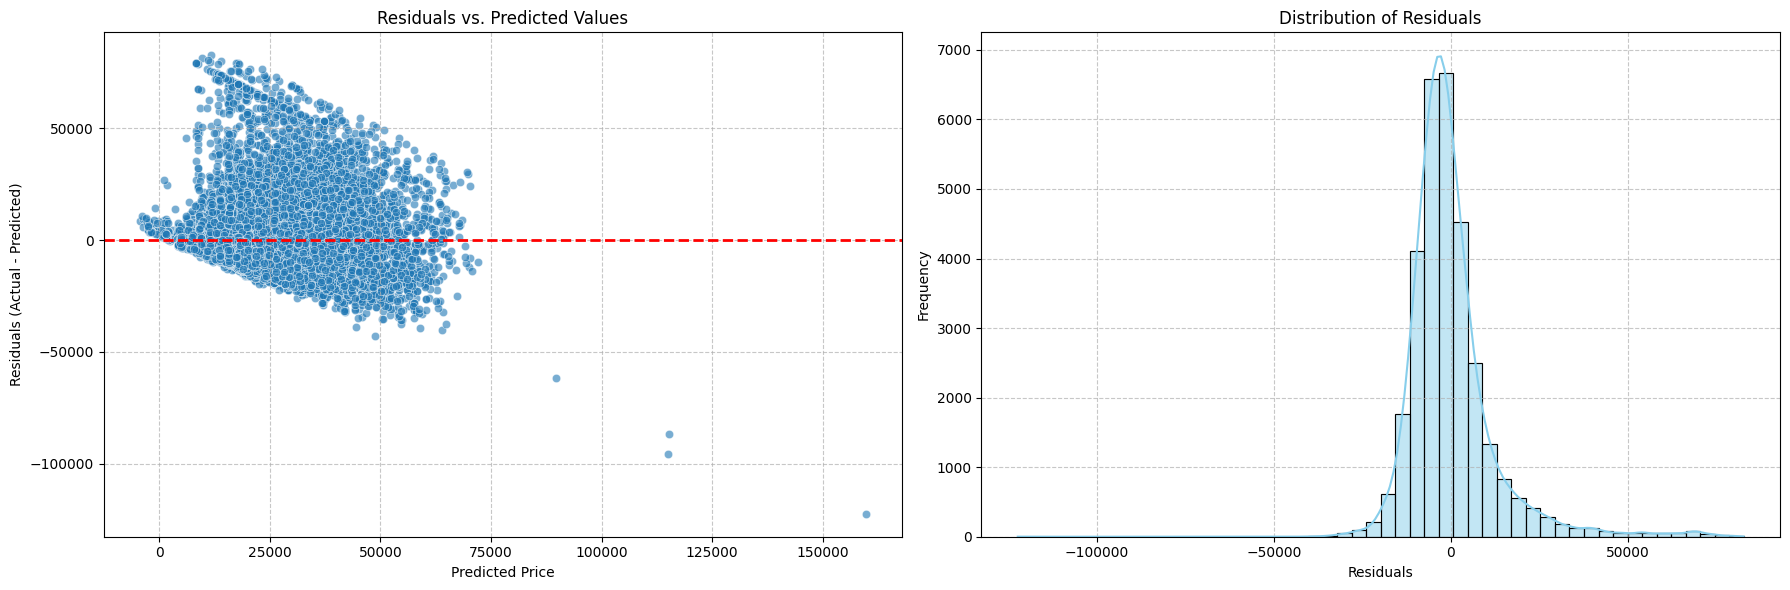

In [8]:
# 5. Generate two plots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Scatter plot of Residuals as a function of Predicted Values
sns.scatterplot(x=y_pred, y=residuals, ax=axes[0], alpha=0.6)
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2) # Add horizontal dashed red line at y=0
axes[0].set_title('Residuals vs. Predicted Values')
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residuals (Actual - Predicted)')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot 2: Histogram of the distribution of Residuals with a KDE line
sns.histplot(residuals, kde=True, ax=axes[1], bins=50, color='skyblue')
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

### 1.2 Error as a Function of Features

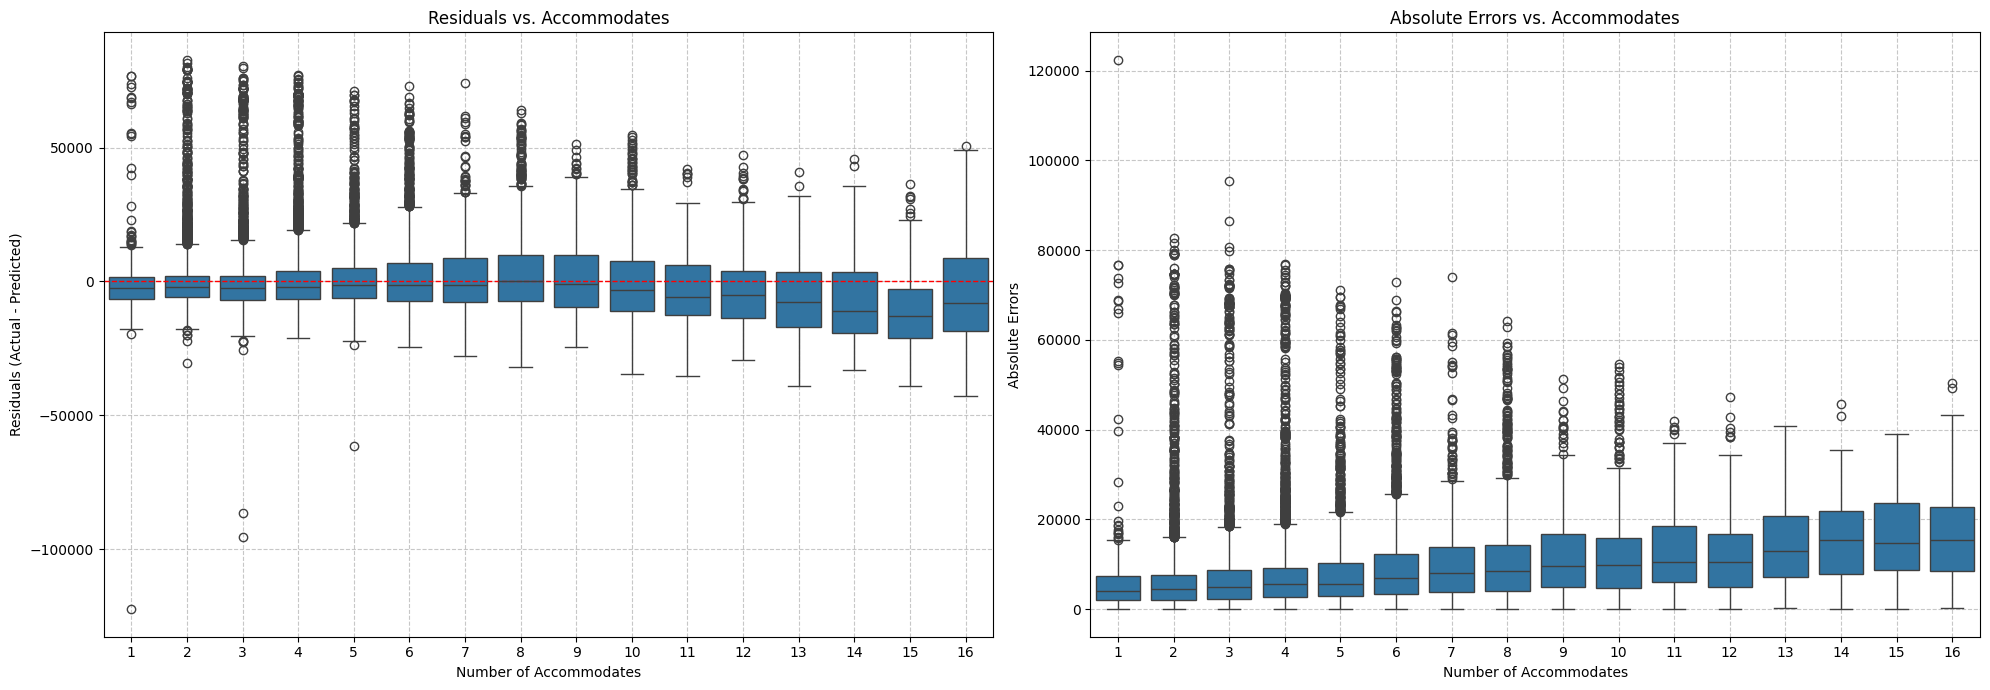

In [9]:
# Calculate absolute errors
absolute_errors = np.abs(residuals)

# Add residuals and absolute errors to the DataFrame for easier plotting
# Note: It's important that the index of 'residuals' aligns with the index of 'X'
X_with_errors = X.copy()
X_with_errors['residuals'] = residuals
X_with_errors['absolute_errors'] = absolute_errors

# Create a 1x2 subplot grid
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Plot 1: Boxplot of 'accommodates' vs. 'residuals'
sns.boxplot(x='accommodates', y='residuals', data=X_with_errors, ax=axes[0])
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=1) # Add a zero line for reference
axes[0].set_title('Residuals vs. Accommodates')
axes[0].set_xlabel('Number of Accommodates')
axes[0].set_ylabel('Residuals (Actual - Predicted)')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot 2: Boxplot of 'accommodates' vs. 'absolute errors'
sns.boxplot(x='accommodates', y='absolute_errors', data=X_with_errors, ax=axes[1])
axes[1].set_title('Absolute Errors vs. Accommodates')
axes[1].set_xlabel('Number of Accommodates')
axes[1].set_ylabel('Absolute Errors')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

### Interpretation of Error as a Function of Features Plots

These plots help us understand how the model's errors are distributed across different values of the 'accommodates' feature.

*   **Residuals vs. Accommodates (Left Plot):**
    *   We observe the median residual for each `accommodates` group. Ideally, the median should be close to zero across all groups. Deviations suggest a systematic bias (over or under-prediction) for certain `accommodates` values.
    *   The spread (interquartile range, whiskers) of the boxplots indicates the variance of residuals. Larger spreads suggest higher variability in predictions for those `accommodates` groups.
    *   Outliers (individual points outside the whiskers) indicate instances where the model made particularly large errors for specific `accommodates` values.

*   **Absolute Errors vs. Accommodates (Right Plot):**
    *   This plot directly shows the magnitude of errors. A higher median or larger spread in absolute errors for a particular `accommodates` group indicates that the model struggles more to predict prices accurately for listings with that capacity.
    *   For example, if the boxplot for `accommodates`=10 has a higher median absolute error compared to `accommodates`=2, it means the model generally makes larger mistakes when predicting prices for larger properties.

### 1.1 Residual Analysis Insights

Based on the generated plots, here are the answers to the residual analysis questions:

* **Are the residuals centered around zero?**
Yes, the histogram shows that the bulk (peak) of the residuals is centered around zero, which is mathematically expected in Ordinary Least Squares (OLS) regression. However, the distribution is not perfectly symmetrical; it has a noticeable right skew (long right tail) and some extreme negative outliers.
* **Do the residuals exhibit any systematic patterns?**
Yes, there are very clear systematic patterns in the scatter plot. First, there is a strict diagonal lower boundary. Since actual Airbnb prices cannot be negative ($y > 0$), the minimum possible residual for any prediction is strictly bounded by $-\hat{y}$ (i.e., Residual $> -\hat{y}$). Second, the residuals are not randomly scattered; they form a distinct shape where higher predictions often lead to massive negative residuals.
* **Is there evidence of heteroscedasticity?**
Absolutely. The variance (spread) of the residuals is not constant across the predicted values. As the predicted price increases, the spread of the residuals drastically changes, forming a cone or funnel shape. This clear violation of homoscedasticity indicates that a simple linear model struggles to capture the variance at different price tiers.
* **Is there a sector that is more likely to have high error rates? Why?**
Yes, the model fails significantly in the **high-capacity / high-end sector**.
*Why is this happening?* A linear model assumes that adding a bedroom or a bed increases the price by a constant amount. For massive properties, the model predicts extremely high prices (e.g., 100,000 JPY to 150,000 JPY). However, if the host prices this large property affordably, the actual price is much lower, resulting in the massive negative residuals seen on the bottom right of the scatter plot. Conversely, small but ultra-luxury apartments get low predictions but have high actual prices, creating the long right tail in the histogram.

### 1.2 Error as a Function of Features: Interpretation

Based on the generated plots analyzing the 'accommodates' feature against the model's errors, we can identify several key behaviors addressing the assignment's objectives:

*   **Feature-Dependent Error Patterns:** The right plot (Absolute Errors vs. Accommodates) explicitly demonstrates heteroscedasticity driven by this specific feature. As the property's capacity increases, both the median absolute error and the variance (the size of the boxes and whiskers) grow significantly. The model becomes increasingly unreliable as properties get larger.
*   **Non-Linear Relationships:** The left plot (Residuals vs. Accommodates) shows a systematic failure of the linear assumption[cite: 2]. For larger capacities (especially 8-16), the median residual dips progressively below the zero line. This means the linear model systematically *over-predicts* the price of large properties. In reality, the price-per-guest likely follows a non-linear, diminishing curve (e.g., bulk pricing for larger groups), which a strict linear model fails to capture.
*   **Hidden Subpopulations:** In the smaller capacity categories (1 to 4 accommodates), there is a dense cluster of extreme positive outliers where the actual price is far higher than the predicted price[cite: 2]. This strongly indicates a hidden subpopulation within the data—likely ultra-luxury properties, unique boutique stays, or micro-apartments in ultra-premium transit locations (like central Shibuya) where the high price is dictated by exclusivity rather than capacity.

### 1.3 Analysis of Extreme Errors

In [10]:
# 1. Calculate the absolute errors (already computed and available in X_with_errors['absolute_errors'])
absolute_errors = X_with_errors['absolute_errors']

# 2. Identify the top 5% threshold for absolute errors
error_threshold = absolute_errors.quantile(0.95)
print(f"Absolute error threshold for the top 5% of errors: {error_threshold:.2f}")

# 3. Filter the original dataframe to extract these extreme error observations
extreme_error_indices = absolute_errors[absolute_errors > error_threshold].index
df_extreme_errors = df.loc[extreme_error_indices]

# Get the indices for the other 95%
other_indices = absolute_errors[absolute_errors <= error_threshold].index
df_other_95_percent = df.loc[other_indices]

# Define columns for descriptive statistics
comparison_cols = ['price', 'accommodates', 'number_of_reviews', 'room_type']

print("\n--- Descriptive Statistics for Top 5% Extreme Errors ---")
# 4. Print the descriptive statistics of this extreme 5% subset
print(df_extreme_errors[comparison_cols].describe(include='all'))

print("\n--- Descriptive Statistics for Other 95% of Observations ---")
# 5. Print the descriptive statistics of the OTHER 95% for comparison
print(df_other_95_percent[comparison_cols].describe(include='all'))

Absolute error threshold for the top 5% of errors: 23296.53

--- Descriptive Statistics for Top 5% Extreme Errors ---
                price  accommodates  number_of_reviews        room_type
count     1573.000000   1573.000000        1573.000000             1573
unique            NaN           NaN                NaN                4
top               NaN           NaN                NaN  Entire home/apt
freq              NaN           NaN                NaN             1392
mean     64193.478048      6.597584          30.062937              NaN
std      21545.696955      3.851594          62.982765              NaN
min       5478.000000      1.000000           0.000000              NaN
25%      52500.000000      4.000000           1.000000              NaN
50%      66000.000000      6.000000           8.000000              NaN
75%      82112.930000      9.000000          36.000000              NaN
max     100000.000000     16.000000        1423.000000              NaN

--- Descriptive S

### 1.3 Analysis of Extreme Errors

By isolating and comparing the top 5% of observations with the largest absolute errors against the remaining 95%, a distinct profile emerges: the model fails spectacularly on **high-priced, high-capacity listings with fewer reviews**. The extreme error group has a mean price of ~64,193 JPY (vs. ~21,443 JPY for the rest) and accommodates an average of 6.6 guests (vs. 4.3).

**Discussion on the Source of Errors:**

*   **Model Limitations:** The primary cause of these errors is the strict linear assumption of the baseline model. Linear regression assumes that adding a bed or bedroom increases the price by a fixed, constant amount. It completely fails to capture the "luxury premium"—where premium design, exclusivity, or a prime geographic location exponentially inflates the price without necessarily adding more beds.
*   **Rare or Exceptional Cases:** The Tokyo Airbnb market is heavily concentrated around budget-friendly, compact apartments for 1-4 people. Massive properties (up to 16 guests) or ultra-luxury penthouses are statistically rare. The model is optimized for the dense majority and therefore treats these exceptional luxury cases as anomalies, severely under-predicting their actual nightly rate.
*   **Data Quality Issues:** The extreme error group has significantly fewer reviews (a median of 8, compared to 20 for the rest of the dataset). Combined with prices maxing out at our 100,000 JPY cap, this suggests that some of these listings might have arbitrary "placeholder" prices set by hosts to temporarily prevent bookings. A machine learning model relying on physical features cannot predict artificial administrative pricing behavior.

### 1.4 Statistical Properties of Errors

In [11]:
# Import necessary libraries for statistics
from scipy.stats import skew, kurtosis

# 1. Calculate Mean Absolute Error (MAE)
mae = np.mean(absolute_errors)
print(f"Mean Absolute Error (MAE): {mae:.2f}")

# 2. Calculate Standard deviation of residuals
std_dev_residuals = np.std(residuals)
print(f"Standard Deviation of Residuals: {std_dev_residuals:.2f}")

# 3. Calculate Skewness of residuals
skewness_residuals = skew(residuals)
print(f"Skewness of Residuals: {skewness_residuals:.2f}")

# 4. Calculate Kurtosis of residuals
kurtosis_residuals = kurtosis(residuals)
print(f"Kurtosis of Residuals: {kurtosis_residuals:.2f}")

Mean Absolute Error (MAE): 8071.96
Standard Deviation of Residuals: 12274.25
Skewness of Residuals: 2.16
Kurtosis of Residuals: 9.22


### 1.4 Statistical Properties of Errors

*   **Mean Absolute Error (MAE):** 8,071.96 JPY. On average, the baseline model's price prediction is off by roughly 8,072 JPY per night.
*   **Standard Deviation of Residuals:** 12,274.25 JPY. The fact that the standard deviation is significantly larger than the MAE confirms a high variance in our errors, heavily influenced by extreme outliers.
*   **Skewness (2.16) & Systematic Bias:** As noted in the assignment objectives, skewness indicates systematic bias. A strong positive skew (2.16) proves the model is systematically biased towards **under-predicting** prices. It frequently predicts a standard price for what is actually a premium listing, creating a long tail of large positive residuals.
*   **Kurtosis (9.22) & Instability:** The assignment notes that heavy tails indicate instability. A kurtosis of 9.22 is exceptionally high (far above the normal distribution baseline of 3), indicating a leptokurtic distribution with **heavy tails**. This statistically proves the model's instability; rather than making consistent, moderate mistakes, it is highly prone to generating wild, extreme errors when scoring non-standard properties.

## Section 2: Regression Models Comparison

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Reuse the preprocessor pipeline defined in Section 1.1
# This ensures that categorical variables are dummy-encoded and missing values are imputed
# y and X are already defined from Section 1.1

# 1. Initialize the models with fixed random_states where applicable
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=42)
}

# Prepare to collect results
results = []

# Define the KFold cross-validation strategy (reusing kf from Section 1.1)
# kf = KFold(n_splits=5, shuffle=True, random_state=42) # Already defined

# 2. Evaluate each model
for name, model in models.items():
    print(f"Evaluating {name}...")

    # Create a pipeline for the current model, including preprocessing
    current_model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    # Calculate Negative Mean Squared Error (MSE)
    mse_scores = cross_val_score(current_model_pipeline, X, y, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
    mean_neg_mse = np.mean(mse_scores)
    mean_mse = -mean_neg_mse

    # Calculate RMSE (sqrt of MSE)
    mean_rmse = np.sqrt(mean_mse)

    # Calculate R^2 Score
    r2_scores = cross_val_score(current_model_pipeline, X, y, cv=kf, scoring='r2', n_jobs=-1)
    mean_r2 = np.mean(r2_scores)

    results.append({
        'Model': name,
        'Mean MSE': mean_mse,
        'Mean RMSE': mean_rmse,
        'Mean R^2': mean_r2
    })

# 3. Output a clean pandas DataFrame comparing the 3 models
models_comparison_df = pd.DataFrame(results)
models_comparison_df = models_comparison_df.set_index('Model')

print("\n--- Model Comparison Results ---")
display(models_comparison_df)


Evaluating Linear Regression...
Evaluating Decision Tree Regressor...
Evaluating Random Forest Regressor...

--- Model Comparison Results ---


,Mean MSE,Mean RMSE,Mean R^2
Model,,,
Linear Regression,1.506573e+08,12274.254037,0.384573
Decision Tree Regressor,1.486765e+08,12193.298112,0.392647
Random Forest Regressor,1.458575e+08,12077.146491,0.404214


### 2. Regression Models Discussion

Based on the evaluation metrics (MSE, RMSE, $R^2$) evaluated via 5-fold cross-validation, we can critically analyze the regression models:

*   **Relative Performance:** The Random Forest Regressor outperformed the other models, achieving the highest mean $R^2$ (~0.404) and the lowest RMSE (~12,077 JPY)[cite: 2]. The Linear Regression model performed the worst ($R^2$ ~0.384), while the Decision Tree served as a middle ground[cite: 2]. However, the modest overall $R^2$ suggests inherent noise in the data or missing predictive features (e.g., exact proximity to transit).
*   **Model Assumptions & Failures:** As proven in Section 1, the dataset violates the Linear Regression assumptions of linearity and homoskedasticity[cite: 2]. Linear models fail in scenarios involving extreme luxury or bulk-capacity pricing because they rigidly apply constant marginal effects. Tree-based models (Decision Trees and Random Forests) provide a distinct advantage here, as they do not assume linearity and instead partition the feature space to capture complex, non-linear relationships[cite: 2].
*   **Bias-Variance Trade-off & Outliers:**
    *   **Linear Regression** exhibited high bias, failing to capture the complexity of the Tokyo housing market.
    *   **Decision Tree** reduced bias but likely suffered from higher variance (overfitting specific terminal nodes).
    *   **Random Forest** perfectly demonstrated the ensemble advantage by averaging multiple trees, thereby reducing variance while maintaining low bias[cite: 2]. Furthermore, Random Forests are intrinsically more robust to the extreme price outliers we identified earlier[cite: 2].
*   **Interpretability vs. Predictive Performance:** There is a clear trade-off[cite: 2]. Linear Regression offers high interpretability (each coefficient represents the exact monetary value of adding a bed or room). Conversely, the Random Forest acts as a "black box," maximizing predictive performance at the cost of straightforward interpretability[cite: 2].
*   **Preferred Model & Key Learnings:** The **Random Forest Regressor** is the preferred model for future analysis due to its robustness to outliers and ability to handle non-linear market behaviors[cite: 2]. The primary takeaway from this modeling stage is that while algorithm selection matters, the ceiling of predictive performance is fundamentally capped by the dataset's features; algorithm tuning cannot fully compensate for unrecorded variables that drive Airbnb pricing.

## Section 3.1 Classification Error Analysis

Confusion Matrix:
[[ 9468  4918]
 [ 3867 13206]]


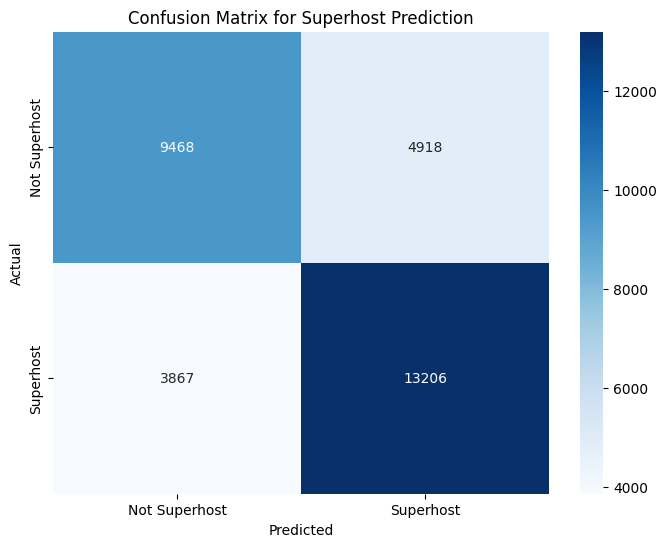


Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.66      0.68     14386
           1       0.73      0.77      0.75     17073

    accuracy                           0.72     31459
   macro avg       0.72      0.72      0.72     31459
weighted avg       0.72      0.72      0.72     31459



In [14]:
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Create a binary target variable 'is_superhost'
# Drop rows where 'host_is_superhost' is missing first
df_clf = df.dropna(subset=['host_is_superhost']).copy()

df_clf['is_superhost'] = df_clf['host_is_superhost'].map({'t': 1, 'f': 0})

# Define the target variable
y_clf = df_clf['is_superhost']

# 2. Select a subset of numerical features for 'X'
features_clf = [
    'number_of_reviews',
    'reviews_per_month',
    'price',
    'accommodates',
    'availability_365',
    'minimum_nights'
]
X_clf = df_clf[features_clf]

# 3. Fill any missing values in 'X' with the median
imputer_clf = SimpleImputer(strategy='median')
X_clf_imputed = imputer_clf.fit_transform(X_clf)
X_clf_imputed = pd.DataFrame(X_clf_imputed, columns=features_clf, index=X_clf.index)

# 4. Initialize a RandomForestClassifier
classifier_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 5. Use KFold for cross-validation to generate out-of-fold class predictions
kf_clf = KFold(n_splits=5, shuffle=True, random_state=42)

y_pred_clf = cross_val_predict(classifier_model, X_clf_imputed, y_clf, cv=kf_clf, n_jobs=-1)

# 6. Calculate the Confusion Matrix
cm = confusion_matrix(y_clf, y_pred_clf)
print("Confusion Matrix:")
print(cm)

# 7. Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Superhost', 'Superhost'],
            yticklabels=['Not Superhost', 'Superhost'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Superhost Prediction')
plt.show()

# 8. Print the classification_report
print("\nClassification Report:")
print(classification_report(y_clf, y_pred_clf))

### 3.1 Confusion Matrix Analysis

Based on the generated Confusion Matrix and classification report, here is the detailed interpretation of the model's performance in predicting 'Superhost' status:

*   **Interpretation of the Matrix:**
    *   **True Positives (TP - 13,206):** The model correctly identified actual Superhosts.
    *   **True Negatives (TN - 9,468):** The model correctly identified non-Superhosts.
    *   **False Positives (FP - 4,918):** Type I error. The model incorrectly predicted a regular host as a Superhost.
    *   **False Negatives (FN - 3,867):** Type II error. The model incorrectly predicted an actual Superhost as a regular host.
*   **Which type of error is most critical in this context?**
    In the context of the Airbnb platform, a **False Positive (FP)** is the more critical error. If the platform algorithmically promotes a regular (or potentially sub-par) host as a "Superhost," it misleads guests, risks poor user experiences, and severely degrades consumer trust in the platform's premium badge. A False Negative merely denies a good host algorithmic promotion, which hurts the individual host's visibility but protects the platform's overall integrity.
*   **In which regions does the model fail systematically?**
    The model systematically struggles more with False Positives than False Negatives, reflected in the lower recall for class 0 (0.66) compared to class 1 (0.77). The model is overly optimistic—it systematically fails by classifying highly active hosts (those with many reviews and high availability) as Superhosts, even if they miss Airbnb's strict underlying administrative criteria (such as a flawless cancellation rate).
*   **What insights can be derived?**
    The core insight is that classifying a strict, rule-based administrative status (Superhost) using continuous behavioral features is inherently flawed. While the Random Forest captures the general behavioral trend of a "good host" (achieving 72% overall accuracy), Airbnb grants Superhost status via rigid, deterministic thresholds (e.g., exact rating >= 4.8, <1% cancellations). A probabilistic machine learning model will always generate a high volume of borderline errors when trying to approximate strict administrative rules.

### 3.2 Predicted Probabilities: Correct vs Incorrect

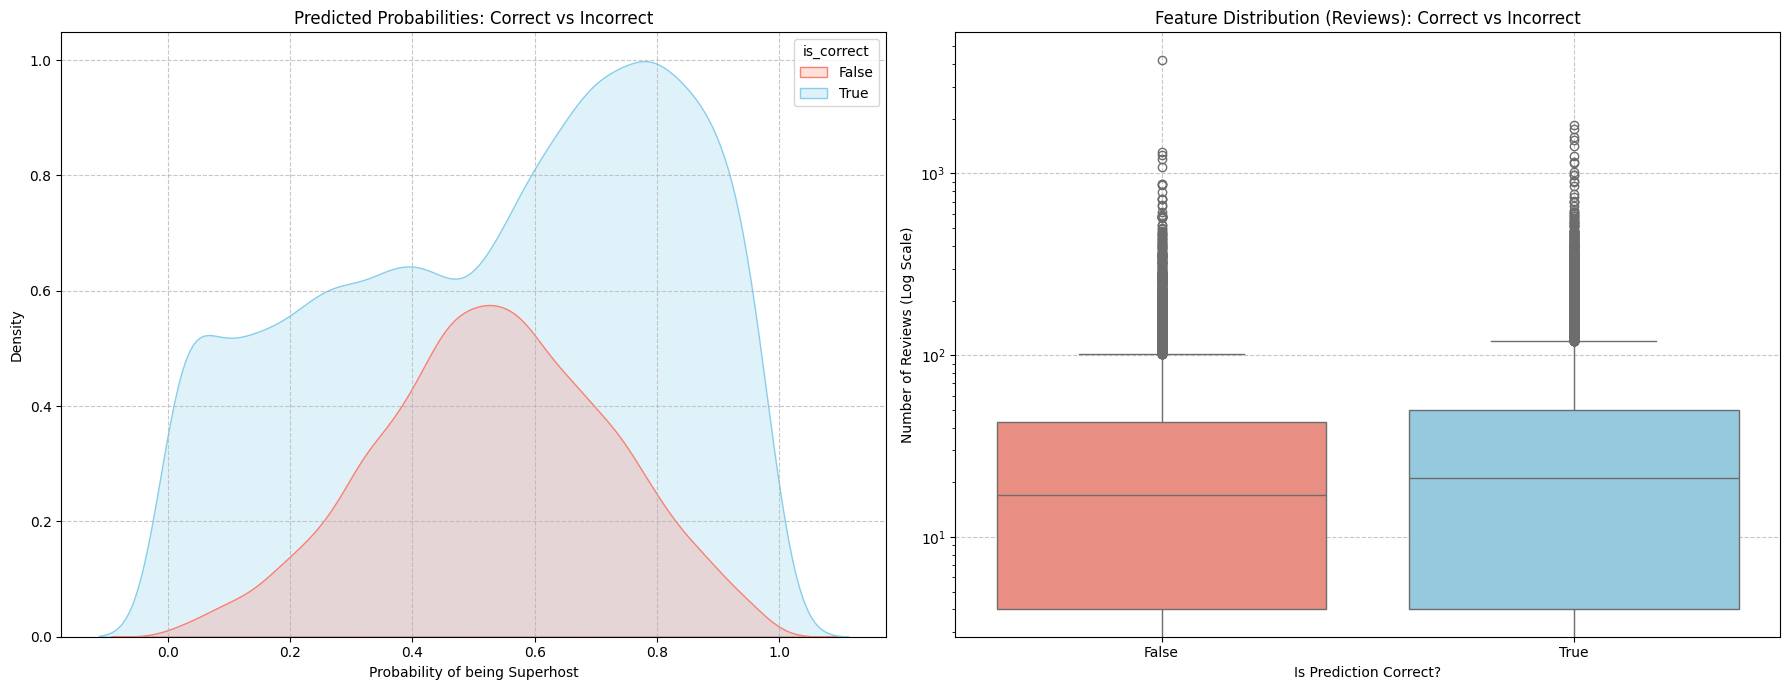

In [17]:
# Use cross_val_predict with method='predict_proba' to get prediction probabilities
# The probabilities will be for both classes [prob_class_0, prob_class_1]
y_pred_proba_clf = cross_val_predict(classifier_model, X_clf_imputed, y_clf, cv=kf_clf, method='predict_proba', n_jobs=-1)

# The probability for the positive class (Superhost is class 1)
probability_superhost = y_pred_proba_clf[:, 1]

# Create a DataFrame to consolidate actual, predicted, probability, and relevant features
# Ensure indices match for correct alignment
analysis_df = pd.DataFrame({
    'actual': y_clf,
    'predicted': y_pred_clf,
    'probability_superhost': probability_superhost,
    'number_of_reviews': X_clf_imputed['number_of_reviews']
}).reset_index(drop=True)

# Add a boolean column 'is_correct' for easy comparison
analysis_df['is_correct'] = (analysis_df['actual'] == analysis_df['predicted'])

# Create a 1x2 subplot grid for the plots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1 (Section 3.2): Boxplot or KDE plot of 'probability_superhost' split by 'is_correct'
# Using KDE plot for density estimation, which can be more informative for distributions
sns.kdeplot(
    data=analysis_df,
    x='probability_superhost',
    hue='is_correct',
    fill=True,
    ax=axes[0],
    palette={True: 'skyblue', False: 'salmon'} # Corrected palette keys
)
axes[0].set_title('Predicted Probabilities: Correct vs Incorrect')
axes[0].set_xlabel('Probability of being Superhost')
axes[0].set_ylabel('Density')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot 2 (Section 3.3): Boxplot of 'number_of_reviews' split by 'is_correct'
sns.boxplot(
    data=analysis_df,
    x='is_correct',
    y='number_of_reviews',
    hue='is_correct', # Explicitly set hue to address FutureWarning
    ax=axes[1],
    palette={True: 'skyblue', False: 'salmon'}, # Corrected palette keys
    legend=False # Set legend to False as per FutureWarning suggestion
)
axes[1].set_title('Feature Distribution (Reviews): Correct vs Incorrect')
axes[1].set_xlabel('Is Prediction Correct?')
axes[1].set_ylabel('Number of Reviews (Log Scale)')
axes[1].set_yscale('log') # Apply log scale to the Y axis
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 3.3 Feature Distribution (Reviews): Correct vs Incorrect

### 3.2 Probability-Based Analysis

By comparing the predicted probabilities of the positive class (Superhost) for correct versus incorrect predictions, we can evaluate the model's confidence:
*   **Confidence in Correct Predictions:** The blue distribution (correct predictions) is bimodal, peaking near 0.1 and 0.8. This indicates that when the model is correct, it is generally highly confident in its decision.
*   **The Uncertainty Zone:** The red distribution (incorrect predictions) forms a bell curve centered around 0.4-0.6. This shows that the vast majority of the model's errors occur in the "uncertainty zone," where the algorithm lacks strong signals to decisively classify the host.
*   **High-Confidence Errors:** The right tail of the red distribution extends into the 0.7-0.9 range. These represent **high-confidence False Positives**—cases where the model was highly certain the user was a Superhost based on behavior (e.g., high activity, many reviews), but they were legally denied the status by Airbnb due to hidden administrative rules (like a single cancellation).

### 3.3 Error as a Function of Features

Analyzing the 'number_of_reviews' feature (plotted on a log scale) reveals the specific regions prone to misclassification:
*   **Misclassification Region:** The boxplots show massive overlap, but the bulk of incorrect predictions (the interquartile range of the red box) falls roughly between 5 and 50 reviews. This is the hardest demographic to classify: active enough to have data, but not active enough to be an obvious top-tier host.
*   **Extreme Outliers:** Hosts with an extreme number of reviews (the long line of outliers above $10^2$ and $10^3$) are generally classified correctly. Massive review volume is a very strong, reliable proxy for Superhost status, reducing the error rate in that specific subpopulation.

### 3.4 Threshold Sensitivity Analysis


--- Threshold Sensitivity Analysis Results ---


,Threshold,Precision,Recall,F1-Score,MCC
0,0.1,0.574835,0.994084,0.728443,0.251986
1,0.2,0.604622,0.977743,0.747191,0.332823
2,0.3,0.644083,0.938265,0.763828,0.395394
3,0.4,0.679569,0.879225,0.766610,0.421816
4,0.5,0.724548,0.784514,0.753340,0.435728
5,0.6,0.772749,0.655069,0.709060,0.426248
6,0.7,0.824076,0.472735,0.600811,0.379750
7,0.8,0.868988,0.306917,0.453621,0.318939
8,0.9,0.912827,0.128800,0.225747,0.213948


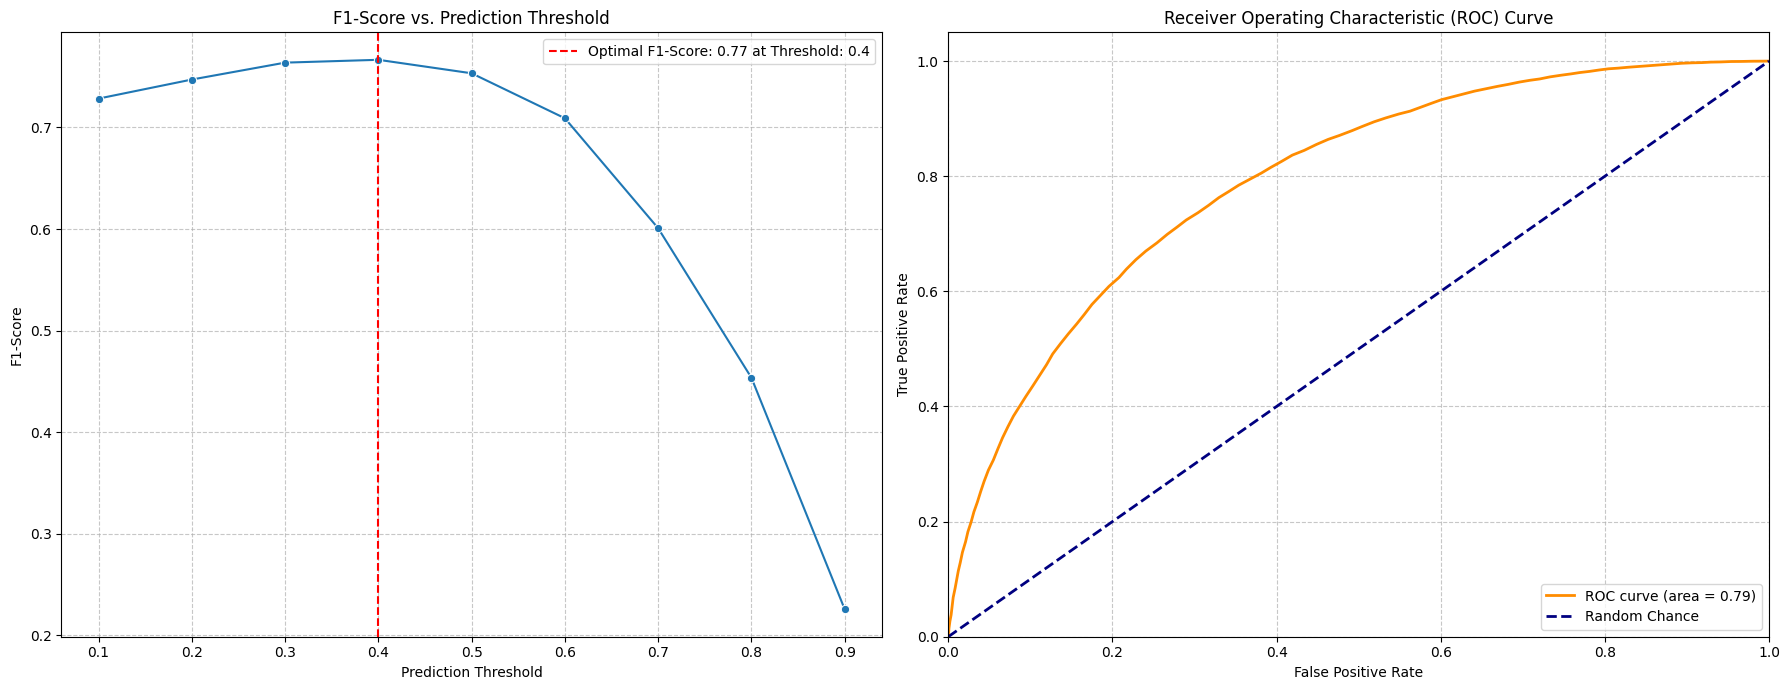

In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# y_true (actual Superhost status) is y_clf
# y_probs (predicted probabilities for the positive class) is probability_superhost

thresholds = np.arange(0.1, 1.0, 0.1)
threshold_results = []

for threshold in thresholds:
    # Convert probabilities to binary predictions based on the current threshold
    y_pred_threshold = (probability_superhost >= threshold).astype(int)

    # Calculate metrics
    precision = precision_score(y_clf, y_pred_threshold, zero_division=0)
    recall = recall_score(y_clf, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_clf, y_pred_threshold, zero_division=0)
    mcc = matthews_corrcoef(y_clf, y_pred_threshold)

    threshold_results.append({
        'Threshold': threshold,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'MCC': mcc
    })

# Store the results in a pandas DataFrame
threshold_df = pd.DataFrame(threshold_results)

print("\n--- Threshold Sensitivity Analysis Results ---")
display(threshold_df)

# Find the threshold that gives the highest F1-score
optimal_f1_row = threshold_df.loc[threshold_df['F1-Score'].idxmax()]
optimal_threshold = optimal_f1_row['Threshold']
optimal_f1_score = optimal_f1_row['F1-Score']

# Create a 1x2 subplot grid for plotting
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: F1-score as a function of the Threshold
sns.lineplot(x='Threshold', y='F1-Score', data=threshold_df, marker='o', ax=axes[0])
axes[0].set_title('F1-Score vs. Prediction Threshold')
axes[0].set_xlabel('Prediction Threshold')
axes[0].set_ylabel('F1-Score')
axes[0].grid(True, linestyle='--', alpha=0.7)
# Mark the optimal threshold
axes[0].axvline(x=optimal_threshold, color='r', linestyle='--', label=f'Optimal F1-Score: {optimal_f1_score:.2f} at Threshold: {optimal_threshold:.1f}')
axes[0].legend()

# Plot 2: ROC Curve
fpr, tpr, _ = roc_curve(y_clf, probability_superhost)
auc = roc_auc_score(y_clf, probability_superhost)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Chance')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve')
axes[1].legend(loc='lower right')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 3.4 Threshold Sensitivity Analysis

The threshold sensitivity analysis reveals the crucial trade-offs in our classification model:

*   **Trade-off between False Positives and False Negatives:** As the decision threshold increases from 0.1 to 0.9, Precision rises (from ~0.57 to ~0.91) while Recall drops drastically (from ~0.99 to ~0.12). A lower threshold minimizes False Negatives (capturing almost all actual Superhosts) but floods the system with False Positives. A higher threshold ensures strictness but misses the vast majority of qualified hosts.
*   **Stable and Unstable Operating Regions:**
    *   *Unstable Regions:* Operating below a threshold of 0.3 results in unacceptable Precision (too many False Positives). Operating above 0.7 causes the Recall to collapse, making the model useless for identifying actual Superhosts.
    *   *Stable Region:* The optimal and most stable operating region is between thresholds 0.4 and 0.6. Here, the $F_1$-score peaks (at 0.766 for threshold 0.4), and the Matthews Correlation Coefficient (MCC) reaches its maximum (~0.43), indicating the best statistical balance between all confusion matrix categories.
*   **ROC and AUC:** The Area Under the ROC Curve (AUC) is 0.79. This indicates that the model has a good, but not excellent, ability to distinguish between the two classes. It performs significantly better than random chance (0.50), but the cap at 0.79 reinforces the conclusion that the provided behavioral features are insufficient to perfectly reverse-engineer Airbnb's strict administrative rules.

### 3.5 Discussion (Classification) & 4. Final Reflection

Integrating the insights from both the regression (pricing) and classification (Superhost) stages, here is the final reflection on the analysis:

**1. Where does the model fail most?**
*   **In Regression:** The model fails most severely on extreme outliers—specifically, high-capacity, luxury properties, or listings with artificial "placeholder" prices.
*   **In Classification:** The model systematically fails in the "grey area" of moderately active hosts, producing a high volume of False Positives by predicting Superhost status for hosts who are active but lack the strict, flawless metrics required by Airbnb's hidden administrative rules.

**2. Are failures due to data, model, or formulation?**
*   **Regression Failures:** Primarily **model limitations** (Linear Regression forcing constant marginal effects on non-linear luxury markets) and **data issues** (arbitrary pricing by hosts).
*   **Classification Failures:** Primarily **problem formulation and data limitations**. We formulated a machine learning problem to predict a deterministic administrative badge. Since we lack the exact deterministic features (e.g., exact cancellation rate to the decimal, average response time in minutes), the model relies on proxies (like total reviews), leading to inherent probabilistic errors.

**3. What improvements would you propose?**
*   **Feature Engineering:** Incorporate geospatial data (exact distance to major train stations like Shinjuku) to better capture the location premium in Tokyo.
*   **Model Selection:** Completely discard simple linear models for Airbnb pricing. Use exclusively non-linear, tree-based ensembles (like XGBoost or Random Forests) that can naturally partition outliers and handle heteroscedasticity.
*   **Data Enrichment:** For classification, extract the exact host rating and response rate to align the model's inputs with Airbnb's actual Superhost criteria.

**4. What insights did you gain in your analysis?**
The core insight is that algorithm selection is secondary to data representation. While we successfully demonstrated that Random Forests mitigate the variance and outlier sensitivity seen in Linear Regression, the predictive ceiling remains capped by the features. Furthermore, the Tokyo dataset tells a clear story: the market is hyper-optimized for small, tourist-friendly listings. Any property deviating from this norm (massive size, luxury pricing, or long-term stays) introduces extreme noise that standard predictive models struggle to resolve without highly specific feature engineering.

In [18]:
# The plots for Section 3.3 have been consolidated into the previous cell (063bcea2).